<a href="https://colab.research.google.com/github/GerardoMunoz/axis/blob/main/Axis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# To Do
# Revisar que los tipos de objetos sean correctos en los constructores y demás argunetos
# En las operaciones de los Join devolver Join y añadir combinación lineal para ahorrar crear objetos intermedios, o crear vectores para esas operaciones


from IPython.display import SVG, display
import math
from math import cos, sin, tan, pi
import ipywidgets as widgets


class Vec:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.xy = (self.x, self.y)

    def __getitem__(self, key):
        return self.xy[key]

    def __add__(self, other):
        return Vec(self[0]+other[0], self[1]+other[1])

    def __radd__(self, other):
        return Vec(self[0]+other[0], self[1]+other[1])

    def __sub__(self, other):
        return Vec(self[0]-other[0], self[1]-other[1])

    def __rsub__(self, other):
        return Vec(-self[0]+other[0], -self[1]+other[1])

    def __mul__(self, other):
        return Vec(self[0]*other, self[1]*other)

    def __rmul__(self, other):
        return Vec(self[0]*other, self[1]*other)

    def __div__(self, other):
        return Vec(self[0]/other, self[1]/other)

    @staticmethod
    def combLin( *listVec):
        """
        list of tuples of (escalar, vector)
        """
        x,y=0,0
        for vec in listVec:
            if isinstance(vec, tuple):
                escalar=vec[0]
                vec=vec[1]
            x+=vec[0]
            y+=vec[1]
        return Vec(x,y)


class Join_graph:
    def __init__(self, canvas,xy, label="",radius=5, color="gray", color_text="gray",font_size="16",move_text=(-10,-4),visible=True):
        self.canvas = canvas
        canvas.add(self)
        self.xy = xy
        self.label = label
        self.radius = radius
        self.color_point = color
        self.color_text = color_text
        self.font_size = font_size
        self.move_text = move_text
        self.visible=visible

    def get_svg(self):
        x, y = self.canvas.transform(self.xy)

        svg = f'\n<circle cx="{x}" cy="{y}" r="{self.radius}" fill="{self.color_point}" />'

        if self.label:
            svg += f'\n<text x="{x + 5}" y="{y - 5}" fill="{self.color_text}" font-size="{self.font_size}">{self.label}</text>'

        return svg
    # def get_svg(self):
    #     svg=""
    #     if self.visible:
    #         svg += f'\n<circle cx="{self.xy[0]}" cy="{self.xy[1]}" r="{self.radius}" fill="{self.color_point}" />'
    #     if self.label:
    #         svg += f'\n<text x="{self.xy[0] + self.move_text[0]}" y="{self.xy[1] + self.move_text[1]}" fill="{self.color_text}" font-size="{self.font_size}">{self.label}</text>'
    #     return svg

    def x(self):
        return self.xy[0]

    def y(self):
        return self.xy[1]

    def __getitem__(self, key):
        return self.xy[key]




class Link_graph:
    def __init__(self,canvas, P0, P1, label="", thickness=3, color="gray", color_text="gray",font_size="16",move_text=(-20,-5)):
        self.canvas = canvas
        canvas.add(self)
        self.P0 = P0
        self.P1 = P1
        self.label = label
        self.thickness = thickness
        self.color_line = color
        self.color_text = color_text
        self.font_size = font_size
        self.move_text = move_text


    def length(self):
        dx = self.P1[0] - self.P0[0]
        dy = self.P1[1] - self.P0[1]
        return math.sqrt(dx*dx + dy*dy)

    def get_svg(self):
        x1, y1 = self.canvas.transform(self.P0)
        x2, y2 = self.canvas.transform(self.P1)

        svg = f'\n<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="{self.color_line}" stroke-width="{self.thickness}"/>'
        I=self
        if I.label:
            # Calculate midpoint for the label
            mid_x = (x1+x2) / 2
            mid_y = (y1+y2) / 2
            svg += f'\n<text x="{mid_x+I.move_text[0]}" y="{mid_y + I.move_text[1]}" fill="{I.color_text}" font-size="{I.font_size}" >{I.label}</text>'#text-anchor="middle"

        return svg

    # def get_svg(I):#, x1, y1, x2, y2, stroke="white", stroke_width=2, label=""):
    #     svg = f'\n<line x1="{I.P0[0]}" y1="{I.P0[1]}" x2="{I.P1[0]}" y2="{I.P1[1]}" stroke="{I.color_line}" stroke-width="{I.thickness}"/>'
    #     if I.label:
    #         # Calculate midpoint for the label
    #         mid_x = (I.P0[0] + I.P1[0]) / 2
    #         mid_y = (I.P0[1] + I.P1[1]) / 2
    #         svg += f'\n<text x="{mid_x+I.move_text[0]}" y="{mid_y + I.move_text[1]}" fill="{I.color_text}" font-size="{I.font_size}" >{I.label}</text>'#text-anchor="middle"
    #     return svg


class Canvas:
    def __init__(I,width=512,height=256,background_color="black",):
        I.width = width
        I.height = height
        I.background_color = background_color
        I.elements = []

    def transform(self, xy):
        return xy

    def add(I,element):
        I.elements.append(element)

    def get_svg(I):
        svg=f"""
<svg width="{I.width}" height="{I.height}" viewBox="0 0 {I.width} {I.height}" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="100%" height="100%" fill="{I.background_color}" />
"""
        for element in I.elements:
            svg+=element.get_svg()
        svg+="""</svg>"""
        return svg


class Axis(Canvas):
    def __init__(self, width=512, height=256,
                 x_min=-1, y_min=-1, x_max=1, y_max=1,
                 background_color="black"):

        super().__init__(width, height, background_color)

        self.x_min = x_min
        self.y_min = y_min
        self.x_max = x_max
        self.y_max = y_max

        # Compute scale
        self.scale_x = width / (x_max - x_min)
        self.scale_y = height / (y_max - y_min)

    def transform(self, xy):
        """
        World → SVG coordinates
        """
        x=xy[0]
        y=xy[1]
        svg_x = (x - self.x_min) * self.scale_x
        svg_y = self.height - (y - self.y_min) * self.scale_y
        return (svg_x, svg_y)


class Angle_graph:
    def __init__(self, canvas, A, B, C, label="", radius=30, color="gray", thickness=2, colo_text="gray",font_size="14",label_d=(10,10)):
        self.canvas = canvas
        canvas.add(self)

        self.A = A
        self.B = B  # vertex
        self.C = C

        self.radius = radius
        self.label = label
        self.color = color
        self.thickness = thickness
        self.color_text = colo_text
        self.font_size = font_size
        self.label_d=label_d

    def normalize(self, vx, vy):
        norm = math.sqrt(vx*vx + vy*vy)
        return vx / norm, vy / norm

    def get_svg(self):

        A = self.canvas.transform(self.A)
        B = self.canvas.transform(self.B)
        C = self.canvas.transform(self.C)
        # Vectors BA and BC
        v1x, v1y = A[0] - B[0], A[1] - B[1]
        v2x, v2y = C[0] - B[0], C[1] - B[1]

        # Normalize
        n1x, n1y = self.normalize(v1x, v1y)
        n2x, n2y = self.normalize(v2x, v2y)


        start_x = B[0] + n1x * self.radius
        start_y = B[1] + n1y * self.radius

        end_x = B[0] + n2x * self.radius
        end_y = B[1] + n2y * self.radius

        # Determine direction using cross product
        cross = v1x * v2y - v1y * v2x
        sweep_flag = 1 if cross > 0 else 0

        # Always use small arc
        large_arc_flag = 0

        svg = f"""
<path d="
M {start_x} {start_y}
A {self.radius} {self.radius} 0 {large_arc_flag} {sweep_flag} {end_x} {end_y}
" stroke="{self.color}" fill="none" stroke-width="{self.thickness}"/>
"""

        # Label position (middle direction)
        mid_dx = n1x + n2x
        mid_dy = n1y + n2y
        mid_len = math.sqrt(mid_dx**2 + mid_dy**2)

        if mid_len != 0:
            mid_dx /= mid_len
            mid_dy /= mid_len

            label_x = B[0] + mid_dx * (self.radius + self.label_d[0])
            label_y = B[1] + mid_dy * (self.radius + self.label_d[1])

            if self.label:
                svg += f'\n<text x="{label_x}" y="{label_y}" fill="{self.color}" font-size="{self.font_size}">{self.label}</text>'

        return svg




<svg width="512" height="256" viewBox="0 0 512 256" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="100%" height="100%" fill="white" />

<circle cx="20" cy="30" r="5" fill="gray" />
<text x="25" y="25" fill="gray" font-size="16">a</text>
<circle cx="200" cy="50" r="5" fill="gray" />
<text x="205" y="45" fill="gray" font-size="16">b</text>
<line x1="20" y1="30" x2="200" y2="50" stroke="gray" stroke-width="3"/>
<text x="90.0" y="35.0" fill="gray" font-size="16" >ab</text></svg>


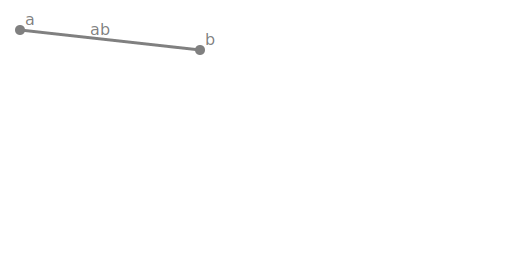

In [13]:

canvas=Canvas(background_color="white")
a=Join_graph(canvas,(20,30),'a')
b=Join_graph(canvas,(200,50),'b')
ab=Link_graph(canvas,a,b,'ab')
svg_code=canvas.get_svg()
print(svg_code)
# Display the SV
display(SVG(svg_code))




<svg width="512" height="256" viewBox="0 0 512 256" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="100%" height="100%" fill="white" />

<circle cx="20" cy="30" r="5" fill="gray" />
<text x="25" y="25" fill="gray" font-size="16">a</text>
<circle cx="200" cy="50" r="5" fill="gray" />
<text x="205" y="45" fill="gray" font-size="16">b</text>
<line x1="20" y1="30" x2="200" y2="50" stroke="gray" stroke-width="3"/>
<text x="90.0" y="35.0" fill="gray" font-size="16" >ab</text>
<circle cx="30" cy="200" r="5" fill="gray" />
<text x="35" y="195" fill="gray" font-size="16">a</text>
<line x1="200" y1="50" x2="30" y2="200" stroke="gray" stroke-width="3"/>
<text x="95.0" y="120.0" fill="gray" font-size="16" >ac</text>
<path d="
M 177.50486433904723 69.84864911260539
A 30 30 0 0 1 170.18348795979142 46.68705421775461
" stroke="gray" fill="none" stroke-width="2"/>

<text x="161.86009402048762" y="62.05601807704173" fill="gray" font-size="14">alpha</text></svg>


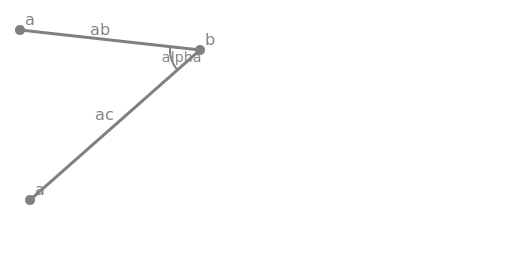

In [14]:


canvas=Canvas(background_color="white")
a1=Join_graph(canvas,(20,30),'a')
b1=Join_graph(canvas,(200,50),'b')
ab1=Link_graph(canvas,a1,b1,'ab')
c1=Join_graph(canvas,(30,200),'a')
ac1=Link_graph(canvas,b1,c1,'ac')
Angle_graph(canvas,c1,b1,a1,"alpha")
svg_code=canvas.get_svg()
print(svg_code)
# Display the SV
display(SVG(svg_code))

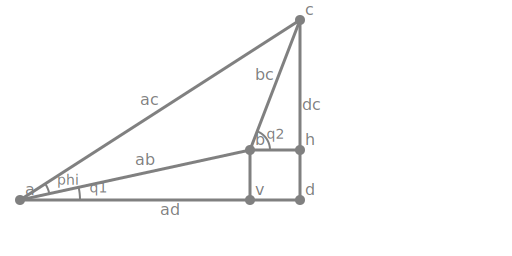

In [15]:
canvas=Canvas(background_color="white")
a=Join_graph(canvas,(20,200),'a')
b=Join_graph(canvas,(250,150),'b',move_text=(-8,-8))
c=Join_graph(canvas,(300,20),'c')
d=Join_graph(canvas,(300,200),'d ')
h=Join_graph(canvas,(300,150),'h')#,visible=False)
v=Join_graph(canvas,(250,200),'v')#,visible=False)
Link_graph(canvas,a,b,'ab',move_text=(0,-10))
Link_graph(canvas,a,c,'ac')
Link_graph(canvas,a,d,'ad',move_text=(0,15))
Link_graph(canvas,b,c,'bc')
Link_graph(canvas,b,h,'')
Link_graph(canvas,b,v,'')
Link_graph(canvas,d,c,'dc',move_text=(2,0))
Angle_graph(canvas,c,a,b,"phi")
Angle_graph(canvas,d,a,b,"q1",radius=60)
Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))
svg_code=canvas.get_svg()
#print(svg_code)
display(SVG(svg_code))

In [16]:
def law_cos_rad(bc,ac,ab):
    return math.acos((ac**2+ab**2-bc**2)/(2*ac*ab))

def law_cos_deg(bc,ac,ab):
    return math.degrees(law_cos_rad(bc,ac,ab))

In [17]:

def update1(c_x):
    canvas1=Axis(width=512,height=512, x_min = 0, y_min = 0, x_max = 512, y_max = 256,background_color="white")
    a1=Join_graph(canvas1,(20,200),'a')
    b1=Join_graph(canvas1,(250,150),'b',move_text=(-8,-8))
    c1=Join_graph(canvas1,(c_x,20),'c')
    ab1=Link_graph(canvas1,a1,b1,'ab',move_text=(0,-10))
    ac1=Link_graph(canvas1,a1,c1,'ac')
    bc1=Link_graph(canvas1,b1,c1,'bc')
    angle=law_cos_deg(bc1.length(),ac1.length(),ab1.length())
    print(bc1.length(),ac1.length(),ab1.length(),angle)
    Angle_graph(canvas1,c1,a1,b1,"phi="+str(int(angle)))
    svg_code=canvas1.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update1, c_x=(10, 400, 1))
#display(SVG(svg_code))

interactive(children=(IntSlider(value=205, description='c_x', max=400, min=10), Output()), _dom_classes=('widg…

<function __main__.update1(c_x)>

In [18]:
def update3(q1_deg,q2_deg):
    q1=q1_deg*pi/180
    q2=q2_deg*pi/180
    canvas=Axis(width=512,height=400, x_min = 0, y_min = 0, x_max = 512, y_max = 400,background_color="white")
    ab_length=300
    bc_length=200
    a_x=20
    a_y=20
    b_x=ab_length*cos(q1)
    b_y=ab_length*sin(q1)
    c_x=b_x+bc_length*cos(q2)
    c_y=b_y+bc_length*sin(q2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a=Join_graph(canvas,(a_x,a_y),'a')
    b=Join_graph(canvas,(b_x,b_y),'b',move_text=(-8,-8))
    c=Join_graph(canvas,(c_x,c_y),'c')
    #d=Join_graph(canvas,(c_x,a_y),'d ')
    h=Join_graph(canvas,(c_x,b_y),'h')#,visible=False)
    v=Join_graph(canvas,(b_x,a_y),'v')#,visible=False)

    ab=Link_graph(canvas,a,b,'ab')#,move_text=(0,-10))
    ac=Link_graph(canvas,a,c,'ac')
    Link_graph(canvas,a,v,'')#,move_text=(0,15))
    #Link_graph(canvas,v,d,'')#,move_text=(0,15))
    bc=Link_graph(canvas,b,c,'bc')
    Link_graph(canvas,b,h,'')
    #Link_graph(canvas,b,v,'ab sin(q1)')
    #Link_graph(canvas,d,h,'')#,move_text=(2,0))
    #Link_graph(canvas,h,c,'bc sin(q2)')#,move_text=(2,0))
    angle=law_cos_deg(bc.length(),ac.length(),ab.length())
    print('phi='+str(int(angle)))
    Angle_graph(canvas,c,a,b,"phi="+str(int(angle)))
    Angle_graph(canvas,v,a,b,"q1",radius=60)
    Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))
    svg_code=canvas.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update3, q1_deg=(10, 40, 1), q2_deg=(-10, 85, 1))

interactive(children=(IntSlider(value=25, description='q1_deg', max=40, min=10), IntSlider(value=37, descripti…

<function __main__.update3(q1_deg, q2_deg)>

# Law of cosines

If a triangle has vertices $a,b,c$ and the length of the segments are $ab, ac,bc$ and $phi$ is the angle between ab and ac, then:

#$$phi=\cos^{-1}\left(\frac{ac^2+ab^2-bc^2}{2(ac)(ab)}\right)$$

#$$bc^2 = ac^2+ab^2 -2(ac)(ab)\cos(phi)$$

In [19]:
def update2(q1_deg,q2_deg):
    q1=q1_deg*pi/180
    q2=q2_deg*pi/180
    canvas=Axis(width=600,height=400, x_min = 0, y_min = 0, x_max = 600, y_max = 400,background_color="white")
    ab_length=300
    bc_length=200
    a_x=20
    a_y=20
    b_x=ab_length*cos(q1)
    b_y=ab_length*sin(q1)
    c_x=b_x+bc_length*cos(q2)
    c_y=b_y+bc_length*sin(q2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a=Join_graph(canvas,(a_x,a_y),'a')
    b=Join_graph(canvas,(b_x,b_y),'b',move_text=(-8,-8))
    c=Join_graph(canvas,(c_x,c_y),'c')
    #d=Join_graph(canvas,(c_x,a_y),'d ')
    h=Join_graph(canvas,(c_x,b_y),'h')#,visible=False)
    v=Join_graph(canvas,(b_x,a_y),'v')#,visible=False)

    Link_graph(canvas,a,b,'')#,move_text=(0,-10))
    #Link_graph(canvas,a,c,'')
    Link_graph(canvas,a,v,'ab cos(q1)='+str(int(b_x-a_x)))#,move_text=(0,15))
    #Link_graph(canvas,v,d,'')#,move_text=(0,15))
    Link_graph(canvas,b,c,'')
    Link_graph(canvas,b,h,'bc cos(q2)='+str(int(c_x-b_x)))
    Link_graph(canvas,b,v,'ab sin(q1)='+str(int(b_y-a_y)))
    #Link_graph(canvas,d,h,'')#,move_text=(2,0))
    Link_graph(canvas,h,c,'bc sin(q2)='+str(int(c_y-b_y)))#,move_text=(2,0))

    #Angle_graph(canvas,c,a,b,"phi")
    Angle_graph(canvas,v,a,b,"q1",radius=60)
    Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))
    svg_code=canvas.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update2, q1_deg=(10, 40, 1), q2_deg=(-10, 85, 1))

interactive(children=(IntSlider(value=25, description='q1_deg', max=40, min=10), IntSlider(value=37, descripti…

<function __main__.update2(q1_deg, q2_deg)>